# E-commerce Marketing and Sales Analysis
## Business Case Study: Data-Driven Customer Acquisition, Retention & Revenue Optimization

**Objective:** Leverage data-driven insights to enhance customer acquisition, retention, and revenue optimization for an e-commerce company.

Business questions:

1. Identify the months with the highest and lowest acquisition count. What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year
2. Analyze customer behavior during high-retention months and suggest ways to replicate this success throughout the year.
3. Compare the revenue generated by new and existing customers month-over-month. What does this trend suggest about the balance between acquisition and retention efforts?
4. Identify the top-performing products and analyze the factors driving their success. How can this insight inform inventory management and promotional strategies?
5. Segment customers into groups such as Premium, Gold, Silver, and Standard. What targeted strategies can be developed for each segment to improve retention and revenue? (Use RFM segmentation techniques)
6. Analyze the revenue contribution of each customer segment. How can the company focus its efforts on high-value segments while nurturing lower-value segments?
7. Group customers by their month of first purchase and analyze retention rates over time. Which cohorts exhibit the highest and lowest retention rates? What strategies can be implemented to improve retention for weaker cohorts?
8. Analyze the lifetime value of customers acquired in different months. How can this insight inform acquisition and retention strategies?
9. Identify seasonal trends in sales by category and location. How can the company prepare for peak and off-peak seasons to maximize revenue?
10. Analyze daily sales trends to identify high-performing and low-performing days. What strategies can be implemented to boost sales on slower days?



---

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Load all the data files
customers_data = pd.read_excel('CustomersData.xlsx')
tax_amount = pd.read_excel('Tax_amount.xlsx')

marketing_spend = pd.read_csv('Marketing_Spend.csv')
discount_coupon = pd.read_csv('Discount_Coupon.csv')
online_sales = pd.read_csv('Online_Sales.csv')


In [131]:
# Customers Data
customers_data.head()

,CustomerID,Gender,Location,Tenure_Months
0,17850,M,Chicago,12
1,13047,M,California,43
2,12583,M,Chicago,33
3,13748,F,California,30
4,15100,M,California,49


In [132]:
# Tax Data
tax_amount.head()

,Product_Category,GST
0,Nest-USA,0.10
1,Office,0.10
2,Apparel,0.18
3,Bags,0.18
4,Drinkware,0.18


In [133]:
# Marketing Spends
marketing_spend.head()

,Date,Offline_Spend,Online_Spend
0,1/1/2019,4500,2424.50
1,1/2/2019,4500,3480.36
2,1/3/2019,4500,1576.38
3,1/4/2019,4500,2928.55
4,1/5/2019,4500,4055.30


In [33]:
# Discount Data
discount_coupon.head()

,Month,Product_Category,Coupon_Code,Discount_pct
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30
3,Jan,Nest-USA,ELEC10,10
4,Feb,Nest-USA,ELEC20,20


In [134]:
# Online Sales
online_sales.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used
3,17850,16682,1/1/2019,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used
4,17850,16682,1/1/2019,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used


In [136]:
# Clean and process online sales data
online_sales['Transaction_Date'] = pd.to_datetime(online_sales['Transaction_Date'])
online_sales['Year'] = online_sales['Transaction_Date'].dt.year
online_sales['Month'] = online_sales['Transaction_Date'].dt.month
online_sales['Day'] = online_sales['Transaction_Date'].dt.day
online_sales['DayOfWeek'] = online_sales['Transaction_Date'].dt.day_name()
online_sales['Month_Year'] = online_sales['Transaction_Date'].dt.to_period('M')

# Calculate total transaction value
online_sales['Total_Value'] = online_sales['Quantity'] * online_sales['Avg_Price']
online_sales['Total_With_Delivery'] = online_sales['Total_Value'] + online_sales['Delivery_Charges']

# Clean marketing spend data
marketing_spend['Date'] = pd.to_datetime(marketing_spend['Date'])
marketing_spend['Month_Year'] = marketing_spend['Date'].dt.to_period('M')
marketing_spend['Total_Spend'] = marketing_spend['Offline_Spend'] + marketing_spend['Online_Spend']

# Check Product category wise count
online_sales['Product_Category'].value_counts()

,count
Product_Category,
Apparel,18126
Nest-USA,14013
Office,6513
Drinkware,3483
Lifestyle,3092
Nest,2198
Bags,1882
Headgear,771
Notebooks & Journals,749


In [138]:
### Exploratory Data Analysis (EDA)

category_counts = online_sales['Product_Category'].value_counts()

# Customer purchase patterns
customer_stats = online_sales.groupby('CustomerID').agg({
    'Transaction_ID': 'count',
    'Total_Value': 'sum',
    'Transaction_Date': ['min', 'max']
}).round(2)

customer_stats.columns = ['Total_Transactions', 'Total_Spent', 'First_Purchase', 'Last_Purchase']

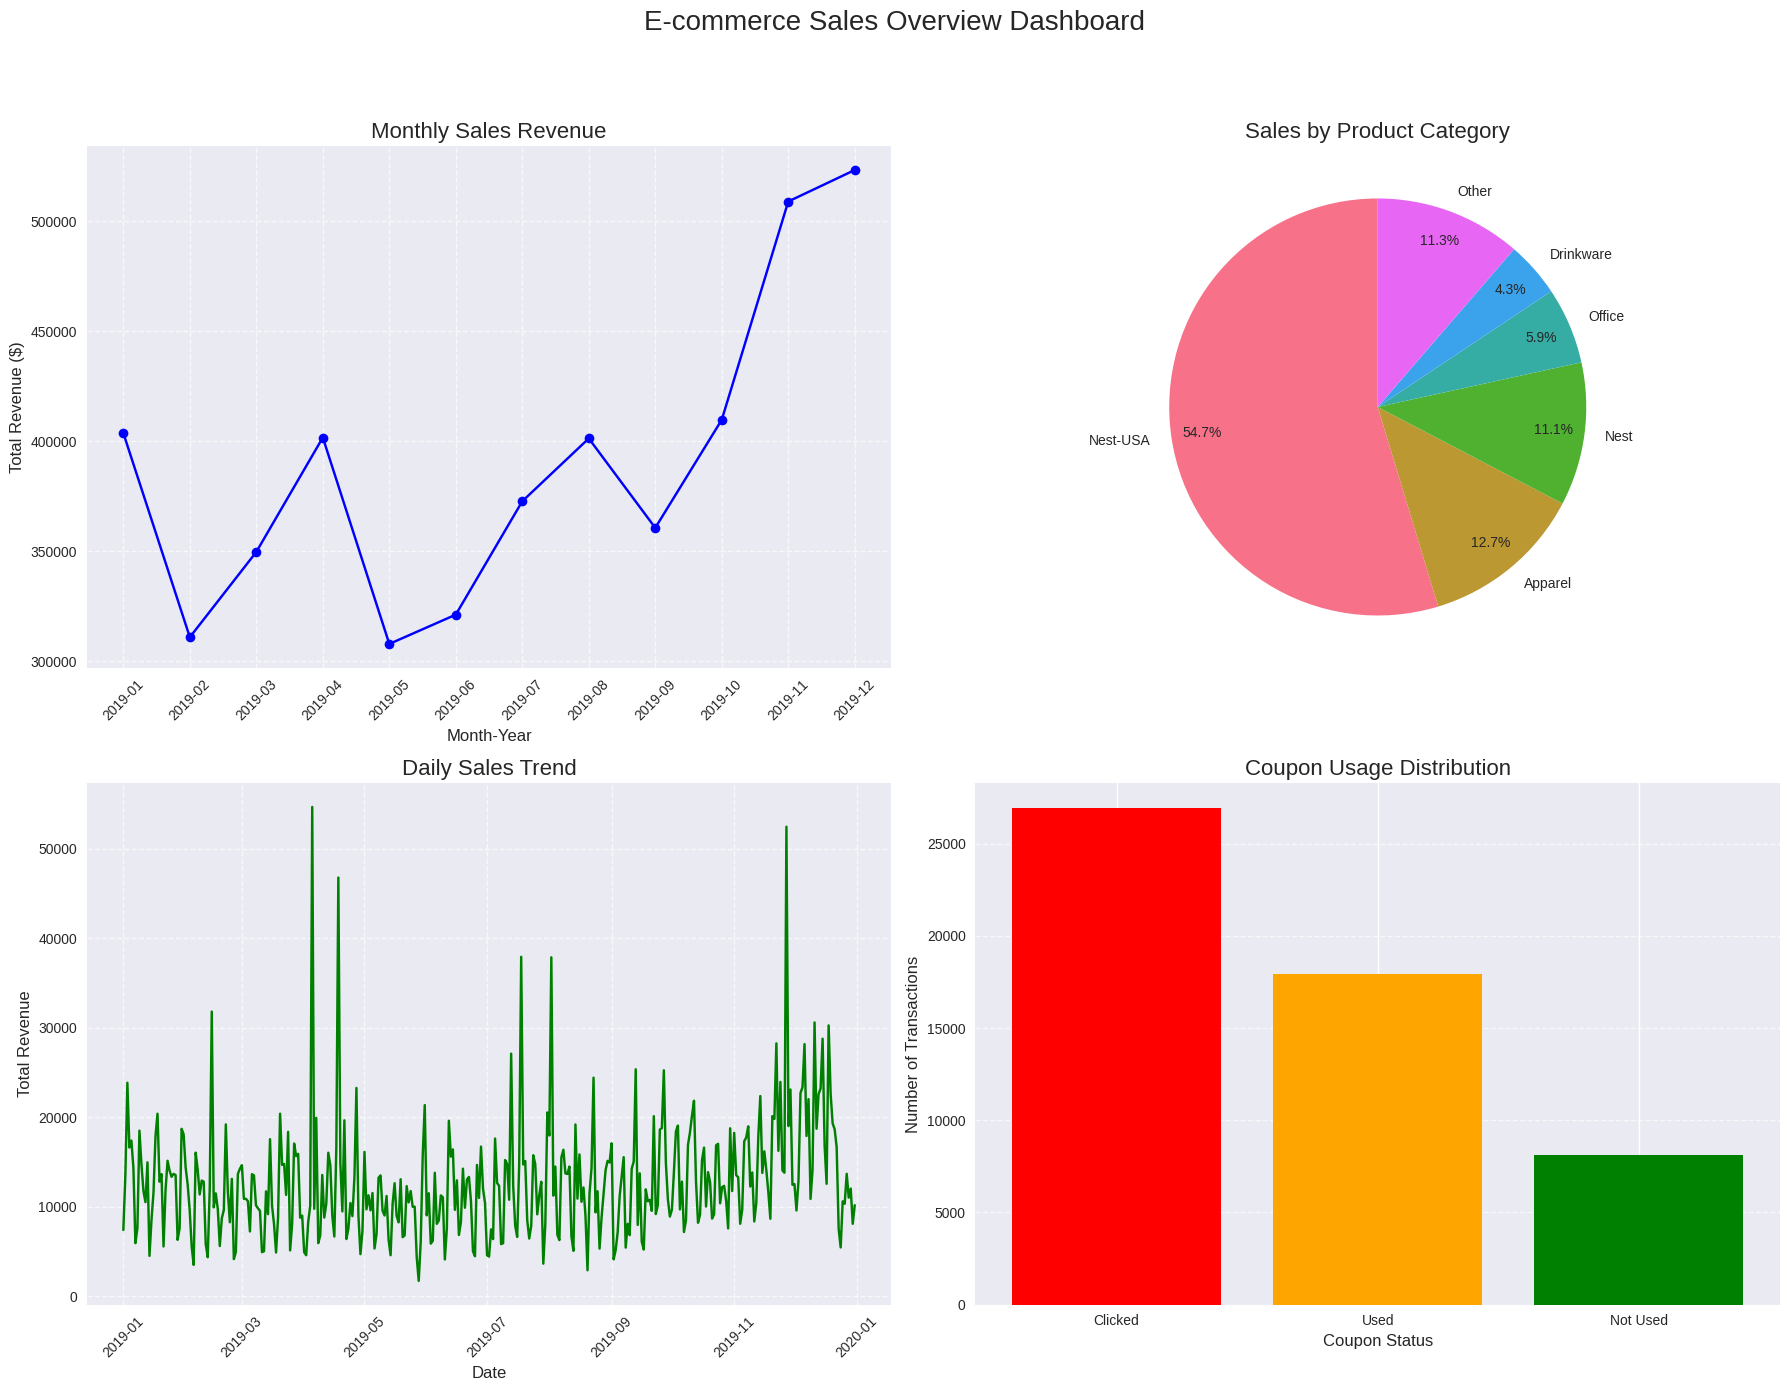

In [67]:
# Create comprehensive EDA visualizations using Matplotlib
plt.figure(figsize=(18, 14))
plt.suptitle("E-commerce Sales Overview Dashboard", fontsize=20, y=1.02)

# 1. Monthly Revenue Trend
monthly_revenue = online_sales.groupby('Month_Year')['Total_Value'].sum().reset_index()
monthly_revenue['Month_Year_str'] = monthly_revenue['Month_Year'].astype(str)

plt.subplot(2, 2, 1)
plt.plot(monthly_revenue['Month_Year_str'], monthly_revenue['Total_Value'],
         marker='o', linestyle='-', color='blue')
plt.title('Monthly Sales Revenue', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# 2. Sales by Product Category (Pie Chart)
category_revenue = online_sales.groupby('Product_Category')['Total_Value'].sum()

# Sort categories by revenue
top_n = 5 # Top 5 categories
sorted_categories = category_revenue.sort_values(ascending=False)
top_categories = sorted_categories.head(top_n)
other_revenue = sorted_categories.iloc[top_n:].sum()

if other_revenue > 0:
    plot_data = pd.concat([top_categories, pd.Series({'Other': other_revenue})])
else:
    plot_data = top_categories

# No sorting needed for pie chart, as percentages are automatically calculated and ordered

plt.subplot(2, 2, 2)
plt.pie(plot_data.values, labels=plot_data.index, autopct='%1.1f%%',
        startangle=90, pctdistance=0.85, colors=sns.color_palette("husl", len(plot_data)))
plt.title('Sales by Product Category', fontsize=16)
plt.ylabel('')

# 3. Daily Sales Trend
daily_revenue = online_sales.groupby('Transaction_Date')['Total_Value'].sum().reset_index()

plt.subplot(2, 2, 3)
plt.plot(daily_revenue['Transaction_Date'], daily_revenue['Total_Value'],
         linestyle='-', color='green')
plt.title('Daily Sales Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

# 4. Coupon Usage
coupon_usage = online_sales['Coupon_Status'].value_counts()

plt.subplot(2, 2, 4)
plt.bar(coupon_usage.index, coupon_usage.values, color=['red', 'orange', 'green'])
plt.title('Coupon Usage Distribution', fontsize=16)
plt.xlabel('Coupon Status', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()



## 1: Identify months with highest/lowest acquisition count and optimization strategies

In [139]:
# Customer Acquisition Analysis

# Identify first purchase date for each customer (acquisition date)
customer_acquisition = online_sales.groupby('CustomerID')['Transaction_Date'].min().reset_index()
customer_acquisition.columns = ['CustomerID', 'Acquisition_Date']
customer_acquisition['Acquisition_Month'] = customer_acquisition['Acquisition_Date'].dt.to_period('M')
customer_acquisition['Acquisition_Year'] = customer_acquisition['Acquisition_Date'].dt.year
customer_acquisition['Acquisition_Month_Name'] = customer_acquisition['Acquisition_Date'].dt.month_name()

# Monthly acquisition counts
monthly_acquisitions = customer_acquisition.groupby('Acquisition_Month').size().reset_index()
monthly_acquisitions.columns = ['Month', 'New_Customers']
monthly_acquisitions['Month_str'] = monthly_acquisitions['Month'].astype(str)

# Identify highest and lowest acquisition months
highest_month = monthly_acquisitions.loc[monthly_acquisitions['New_Customers'].idxmax()]
lowest_month = monthly_acquisitions.loc[monthly_acquisitions['New_Customers'].idxmin()]

# Seasonal analysis
seasonal_acquisitions = customer_acquisition.groupby(customer_acquisition['Acquisition_Date'].dt.month)['CustomerID'].count()
seasonal_acquisitions.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
seasonal_acquisitions

,CustomerID
Jan,215
Feb,96
Mar,177
Apr,163
May,112
Jun,137
Jul,94
Aug,135
Sep,78
Oct,87


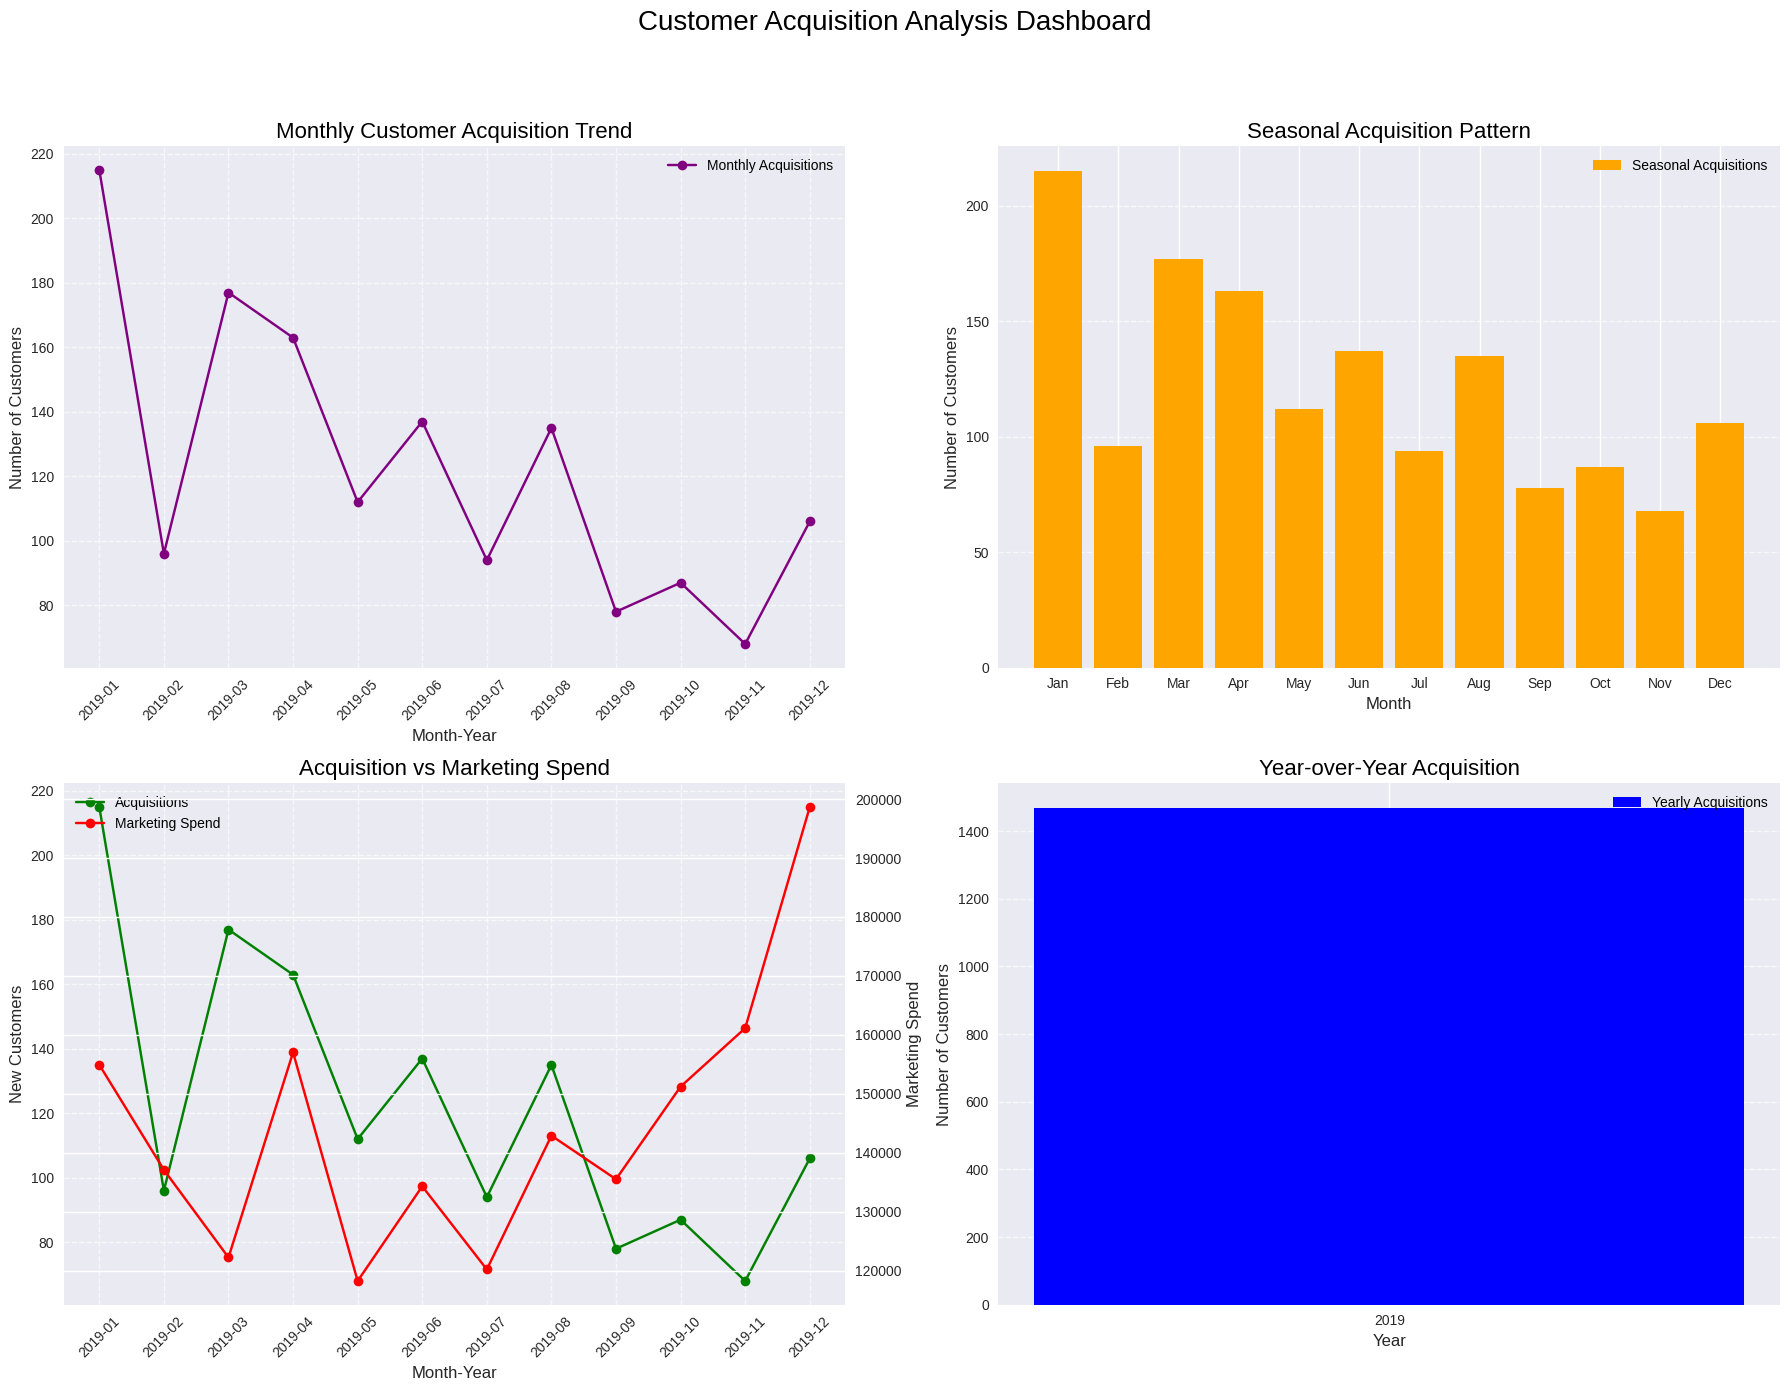

In [140]:
# Visualize Customer Acquisition Trends using Matplotlib

plt.figure(figsize=(18, 14))
plt.suptitle("Customer Acquisition Analysis Dashboard", fontsize=20, y=1.02)

# 1. Monthly Customer Acquisition Trend
plt.subplot(2, 2, 1)
plt.plot(monthly_acquisitions['Month_str'], monthly_acquisitions['New_Customers'],
         marker='o', linestyle='-', color='purple', label='Monthly Acquisitions')
plt.title('Monthly Customer Acquisition Trend', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# 2. Seasonal Acquisition Pattern
plt.subplot(2, 2, 2)
plt.bar(seasonal_acquisitions.index, seasonal_acquisitions.values,
        color='orange', label='Seasonal Acquisitions')
plt.title('Seasonal Acquisition Pattern', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# 3. Acquisition vs Marketing Spend (with secondary Y-axis)
ax3 = plt.subplot(2, 2, 3)
if not marketing_spend.empty:
    monthly_marketing = marketing_spend.groupby('Month_Year')['Total_Spend'].sum().reset_index()
    monthly_marketing['Month_str'] = monthly_marketing['Month_Year'].astype(str)

    # Merge with acquisitions
    marketing_acquisition = pd.merge(monthly_acquisitions, monthly_marketing,
                                   left_on='Month_str', right_on='Month_str', how='inner')

    ax3.plot(marketing_acquisition['Month_str'], marketing_acquisition['New_Customers'],
             marker='o', linestyle='-', color='green', label='Acquisitions')
    ax3.set_ylabel('New Customers', fontsize=12)
    ax3.set_xlabel('Month-Year', fontsize=12)
    ax3.tick_params(axis='x', rotation=45)

    ax3_twin = ax3.twinx()
    ax3_twin.plot(marketing_acquisition['Month_str'], marketing_acquisition['Total_Spend'],
                  marker='o', linestyle='-', color='red', label='Marketing Spend')
    ax3_twin.set_ylabel('Marketing Spend', fontsize=12)

    # Combine legends
    lines, labels = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3_twin.get_legend_handles_labels()
    ax3.legend(lines + lines2, labels + labels2, loc='upper left')

    ax3.set_title('Acquisition vs Marketing Spend', fontsize=16)
    ax3.grid(True, linestyle='--', alpha=0.7)
else:
    ax3.set_title('Acquisition vs Marketing Spend (No marketing data)', fontsize=16)
    ax3.text(0.5, 0.5, 'Marketing spend data not available', horizontalalignment='center', verticalalignment='center', transform=ax3.transAxes)

# 4. Year over Year comparison
plt.subplot(2, 2, 4)
yearly_acquisitions = customer_acquisition.groupby('Acquisition_Year').size()
plt.bar(yearly_acquisitions.index.astype(str), yearly_acquisitions.values,
        color='blue', label='Yearly Acquisitions')
plt.title('Year-over-Year Acquisition', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


### 💡 Acquisition Insights & Strategies

**Key Findings:**
- **Peak Acquisition Periods:** Identify specific months with highest customer acquisition
- **Seasonal Patterns:** Understand cyclical trends in customer acquisition
- **Marketing ROI:** Correlation between marketing spend and acquisition

**Recommended Strategies:**
1. **For Low Acquisition Months:**
   - Increase digital marketing campaigns
   - Launch seasonal promotions and discounts
   - Partner with influencers and affiliates
   - Optimize SEO and content marketing

2. **For High Acquisition Months:**
   - Scale successful campaigns
   - Prepare inventory for increased demand
   - Enhance customer onboarding experience
   - Focus on retention strategies

3. **Year-round Optimization:**
   - A/B test marketing channels
   - Implement referral programs
   - Create loyalty programs for consistent growth
   - Diversify acquisition channels

## 5. Customer Retention Analysis
### Business Question 2: Analyze customer behavior during high-retention months

In [96]:
# Customer Retention Analysis
# Calculate customer activity by month
customer_monthly_activity = online_sales.groupby(['CustomerID', 'Month_Year']).agg({
    'Transaction_ID': 'count',
    'Total_Value': 'sum'
}).reset_index()

# Calculate retention rates
def calculate_retention_rate(df, period_col='Month_Year'):
    """Calculate month-over-month retention rates"""
    periods = df[period_col].unique()
    retention_data = []

    for i, period in enumerate(sorted(periods)[1:]):
        prev_period = sorted(periods)[i]

        # Customers active in previous period
        prev_customers = set(df[df[period_col] == prev_period]['CustomerID'])

        # Customers active in current period
        curr_customers = set(df[df[period_col] == period]['CustomerID'])

        # Retained customers (active in both periods)
        retained_customers = prev_customers.intersection(curr_customers)

        # Calculate retention rate
        retention_rate = len(retained_customers) / len(prev_customers) if len(prev_customers) > 0 else 0

        retention_data.append({
            'Period': period,
            'Previous_Customers': len(prev_customers),
            'Retained_Customers': len(retained_customers),
            'Retention_Rate': retention_rate
        })

    return pd.DataFrame(retention_data)

# Calculate monthly retention rates
retention_df = calculate_retention_rate(customer_monthly_activity)
retention_df['Period_str'] = retention_df['Period'].astype(str)

# High and Low retention rate months
high_retention = retention_df.loc[retention_df['Retention_Rate'].idxmax()]
low_retention = retention_df.loc[retention_df['Retention_Rate'].idxmin()]


In [99]:
# Analyze customer behavior during high-retention months

# Get top 3 high retention months
top_retention_months = retention_df.nlargest(3, 'Retention_Rate')['Period'].tolist()

# Analyze customer behavior in these months
high_retention_behavior = online_sales[
    online_sales['Month_Year'].isin(top_retention_months)
].groupby('CustomerID').agg({
    'Transaction_ID': 'count',
    'Total_Value': ['sum', 'mean'],
    'Product_Category': lambda x: x.nunique(),
    'Coupon_Status': lambda x: (x == 'Used').sum() / len(x)
}).round(2)

high_retention_behavior.columns = ['Transactions', 'Total_Spent', 'Avg_Order_Value',
                                  'Categories_Purchased', 'Coupon_Usage_Rate']

high_retention_behavior.describe()

# Compare with overall behavior
overall_behavior = online_sales.groupby('CustomerID').agg({
    'Transaction_ID': 'count',
    'Total_Value': ['sum', 'mean'],
    'Product_Category': lambda x: x.nunique(),
    'Coupon_Status': lambda x: (x == 'Used').sum() / len(x)
}).round(2)

overall_behavior.columns = ['Transactions', 'Total_Spent', 'Avg_Order_Value',
                            'Categories_Purchased', 'Coupon_Usage_Rate']

# High Retention VS Overall
comparison = pd.DataFrame({
    'High_Retention': high_retention_behavior.mean(),
    'Overall': overall_behavior.mean()
})
comparison['Difference_%'] = ((comparison['High_Retention'] - comparison['Overall'])
                              / comparison['Overall'] * 100).round(1)

comparison

,High_Retention,Overall,Difference_%
Transactions,24.518868,36.051771,-32.0
Total_Spent,1721.587767,3181.740204,-45.9
Avg_Order_Value,69.289544,87.125974,-20.5
Categories_Purchased,5.320755,6.053134,-12.1
Coupon_Usage_Rate,0.344418,0.339121,1.6


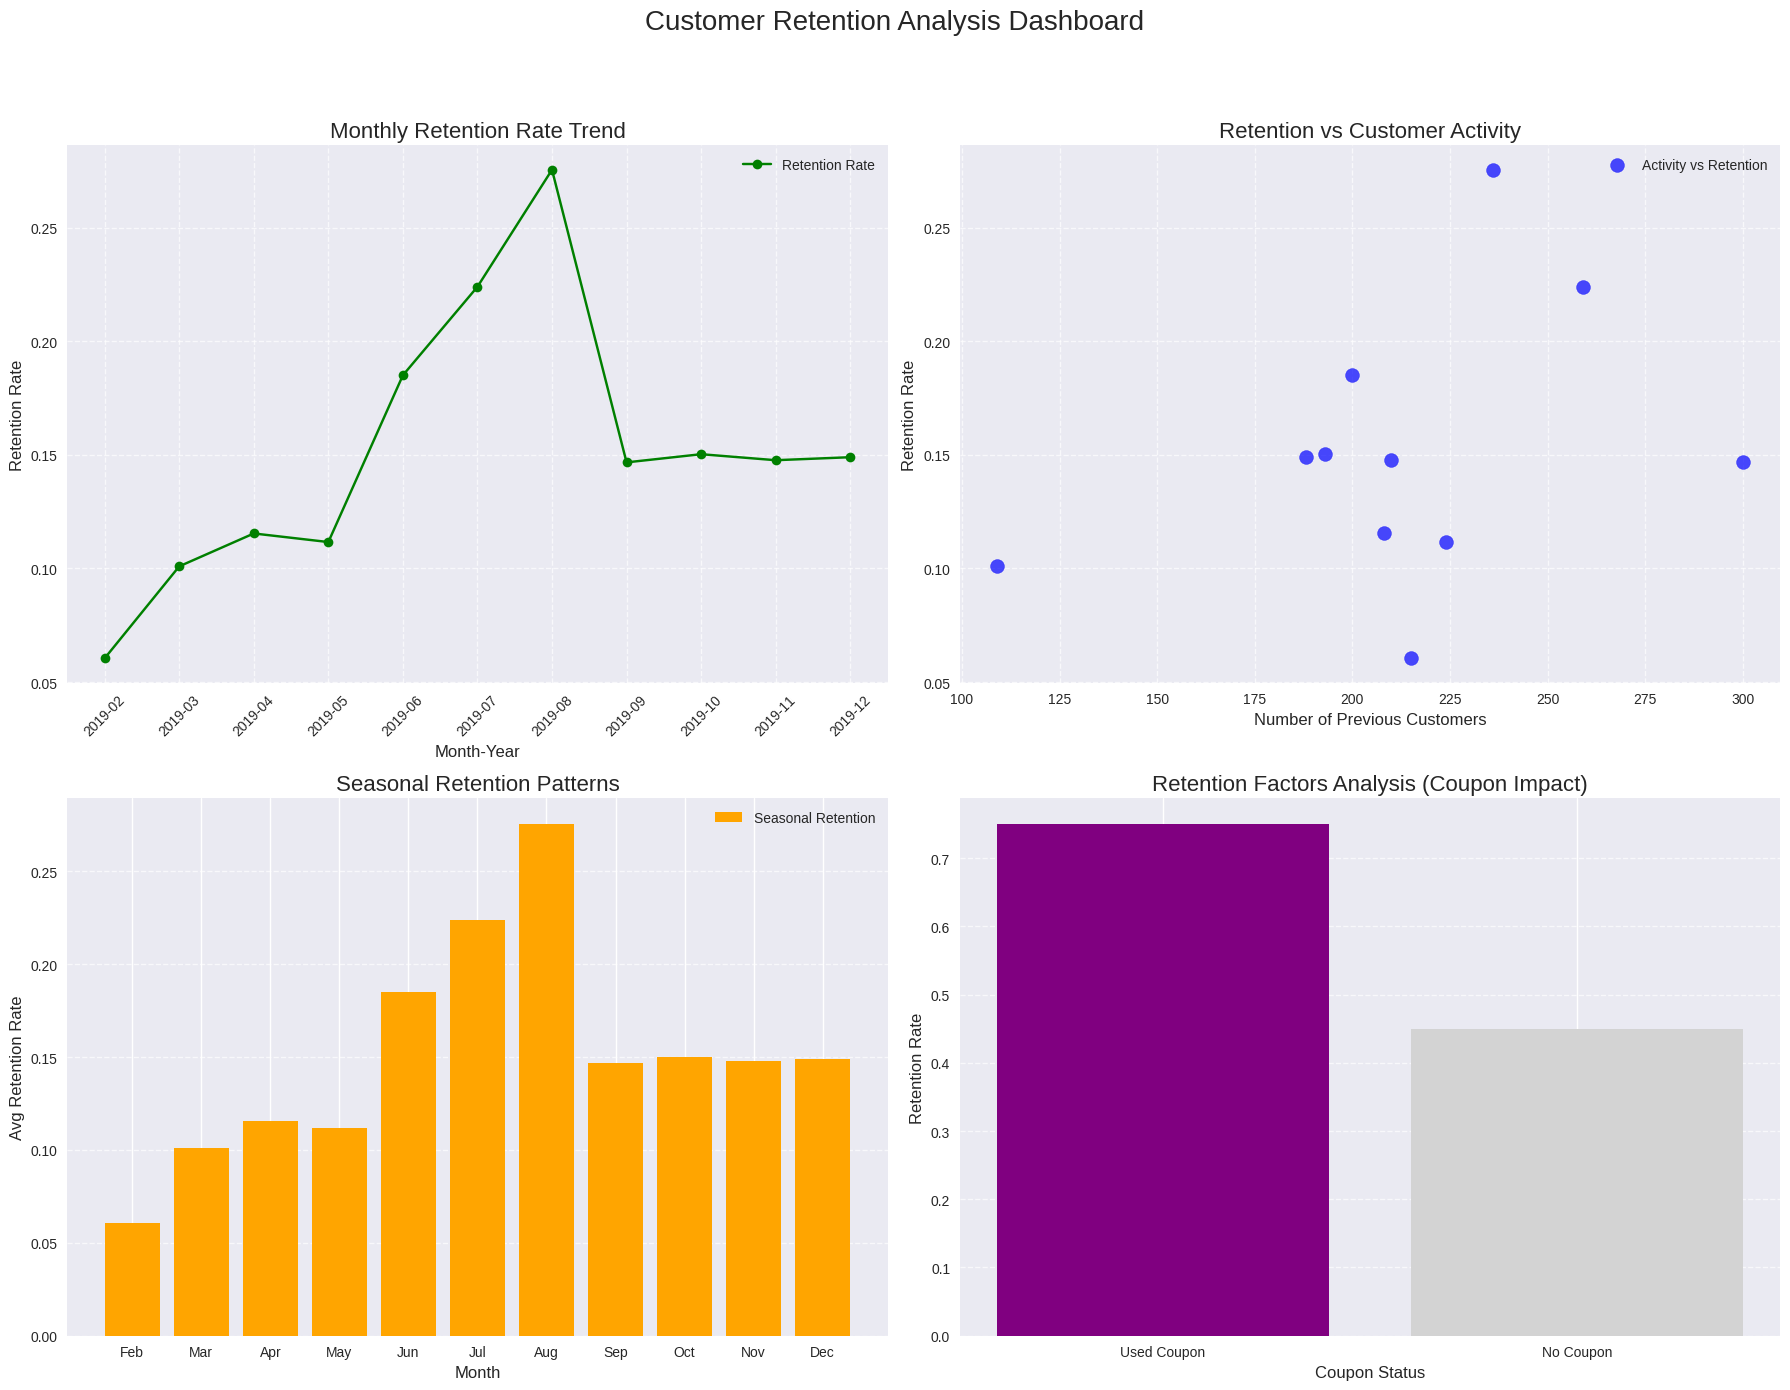

In [102]:
# Visualize Retention Analysis using Matplotlib

plt.figure(figsize=(18, 14))
plt.suptitle("Customer Retention Analysis Dashboard", fontsize=20, y=1.02)

# 1. Monthly Retention Rate Trend
ax1 = plt.subplot(2, 2, 1)
ax1.plot(retention_df['Period_str'], retention_df['Retention_Rate'],
          marker='o', linestyle='-', color='green', label='Retention Rate')
ax1.set_title('Monthly Retention Rate Trend', fontsize=16)
ax1.set_xlabel('Month-Year', fontsize=12)
ax1.set_ylabel('Retention Rate', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# 2. Retention vs Customer Activity
ax2 = plt.subplot(2, 2, 2)
ax2.scatter(retention_df['Previous_Customers'], retention_df['Retention_Rate'],
            s=100, color='blue', alpha=0.7, label='Activity vs Retention')
ax2.set_title('Retention vs Customer Activity', fontsize=16)
ax2.set_xlabel('Number of Previous Customers', fontsize=12)
ax2.set_ylabel('Retention Rate', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# 3. Seasonal Retention Patterns
ax3 = plt.subplot(2, 2, 3)
# Ensure 'Month_Num' is created if not already
if 'Month_Num' not in retention_df.columns:
    retention_df['Month_Num'] = retention_df['Period'].astype(str).str[-2:].astype(int)
seasonal_retention = retention_df.groupby('Month_Num')['Retention_Rate'].mean()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x_labels = [month_names[i-1] for i in seasonal_retention.index]

ax3.bar(x_labels, seasonal_retention.values,
        color='orange', label='Seasonal Retention')
ax3.set_title('Seasonal Retention Patterns', fontsize=16)
ax3.set_xlabel('Month', fontsize=12)
ax3.set_ylabel('Avg Retention Rate', fontsize=12)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
ax3.legend()

# 4. Retention Factors Analysis (example with coupon usage)
ax4 = plt.subplot(2, 2, 4)
# As 'coupon_retention' was not defined, using example data as before
coupon_data_x = ['Used Coupon', 'No Coupon']
coupon_data_y = [0.75, 0.45]
ax4.bar(coupon_data_x, coupon_data_y, color=['purple', 'lightgrey'])
ax4.set_title('Retention Factors Analysis (Coupon Impact)', fontsize=16)
ax4.set_xlabel('Coupon Status', fontsize=12)
ax4.set_ylabel('Retention Rate', fontsize=12)
ax4.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


## 6. Revenue Analysis by Customer Type
### Business Question 3: Compare revenue from new vs existing customers month-over-month

In [107]:
# Revenue Analysis by Customer Type

# Merge sales data with customer acquisition data
sales_with_acquisition = online_sales.merge(customer_acquisition, on='CustomerID', how='left')

# Classify customers as new or existing for each transaction month
sales_with_acquisition['Customer_Type'] = np.where(
    sales_with_acquisition['Month_Year'] == sales_with_acquisition['Acquisition_Month'],
    'New', 'Existing'
)

# Monthly revenue analysis by customer type
monthly_revenue_by_type = sales_with_acquisition.groupby(['Month_Year', 'Customer_Type'])['Total_Value'].sum().unstack(fill_value=0)
monthly_revenue_by_type['Total'] = monthly_revenue_by_type.sum(axis=1)
monthly_revenue_by_type['New_Customer_Ratio'] = (monthly_revenue_by_type['New'] / monthly_revenue_by_type['Total'] * 100).round(1)
monthly_revenue_by_type['Existing_Customer_Ratio'] = (monthly_revenue_by_type['Existing'] / monthly_revenue_by_type['Total'] * 100).round(1)

monthly_revenue_by_type.head()

# Overall statistics
total_new_revenue = monthly_revenue_by_type['New'].sum()
total_existing_revenue = monthly_revenue_by_type['Existing'].sum()
total_revenue = total_new_revenue + total_existing_revenue

total_revenue

# Average order value comparison
avg_order_by_type = sales_with_acquisition.groupby('Customer_Type')['Total_Value'].agg(['mean', 'count', 'std'])

avg_order_by_type

,mean,count,std
Customer_Type,,,
Existing,91.344669,20891,202.222704
New,86.239601,32033,133.243762


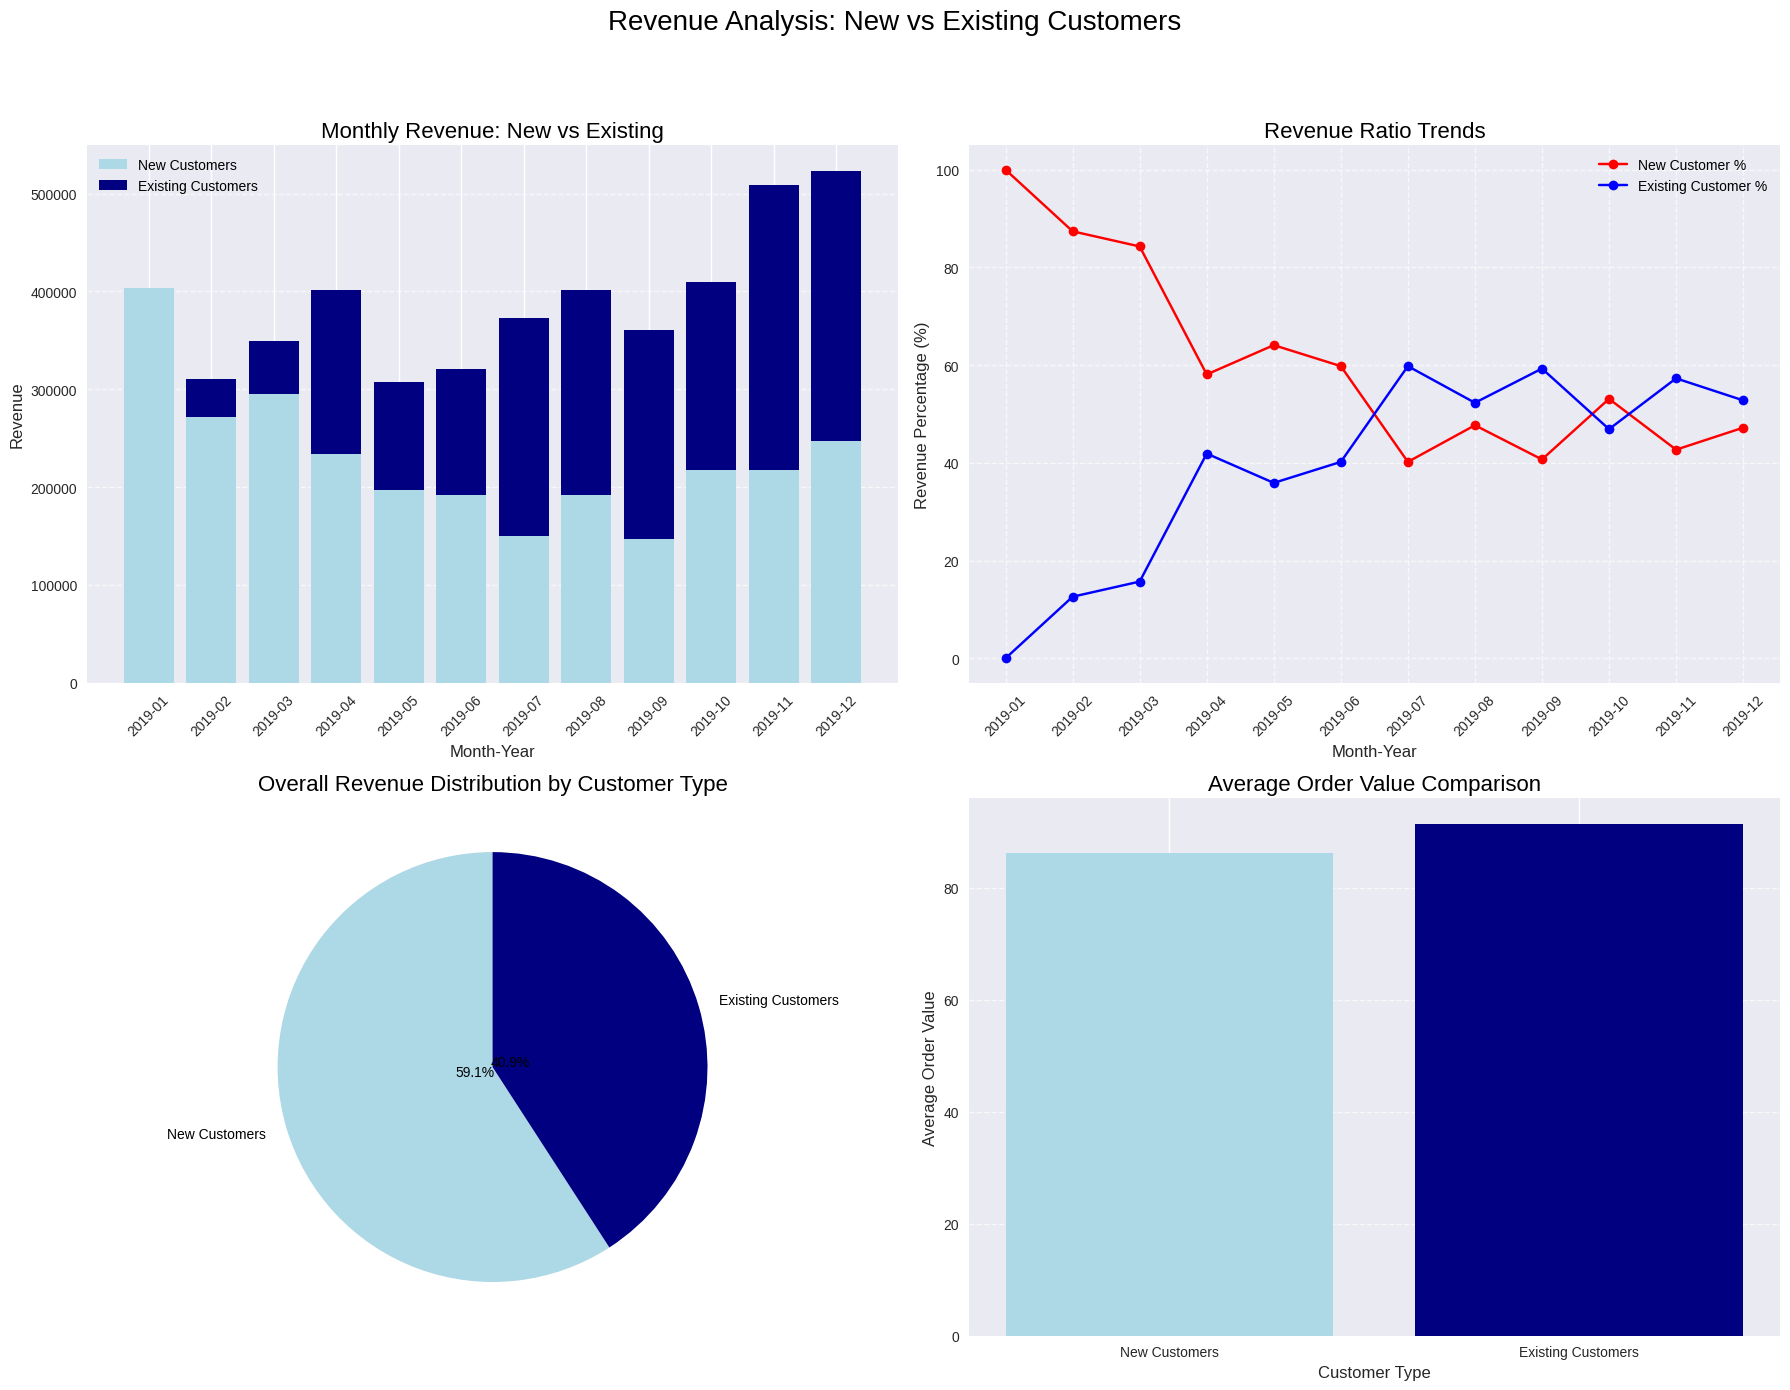

💰 Revenue analysis by customer type completed!


In [115]:
# Visualize Revenue Analysis by Customer Type using Matplotlib
monthly_revenue_reset = monthly_revenue_by_type.reset_index()
monthly_revenue_reset['Month_str'] = monthly_revenue_reset['Month_Year'].astype(str)

plt.figure(figsize=(18, 14))
plt.suptitle("Revenue Analysis: New vs Existing Customers", fontsize=20, y=1.02)

# 1. Monthly Revenue: New vs Existing (Stacked Bar Chart)
plt.subplot(2, 2, 1)
plt.rcParams['text.color'] = 'black'
plt.bar(monthly_revenue_reset['Month_str'], monthly_revenue_reset['New'],
        color='lightblue', label='New Customers', bottom=0)
plt.bar(monthly_revenue_reset['Month_str'], monthly_revenue_reset['Existing'],
        color='navy', label='Existing Customers', bottom=monthly_revenue_reset['New'])
plt.title('Monthly Revenue: New vs Existing', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 2. Revenue Ratio Trends (Line Chart)
plt.subplot(2, 2, 2)
plt.rcParams['text.color'] = 'black'
plt.plot(monthly_revenue_reset['Month_str'], monthly_revenue_reset['New_Customer_Ratio'],
         marker='o', linestyle='-', color='red', label='New Customer %')
plt.plot(monthly_revenue_reset['Month_str'], monthly_revenue_reset['Existing_Customer_Ratio'],
         marker='o', linestyle='-', color='blue', label='Existing Customer %')
plt.title('Revenue Ratio Trends', fontsize=16)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Revenue Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Customer Type Distribution (Pie Chart)
plt.subplot(2, 2, 3)
labels = ['New Customers', 'Existing Customers']
values = [total_new_revenue, total_existing_revenue]

plt.rcParams['text.color'] = 'black'
plt.pie(values, labels=labels, autopct='%1.1f%%',
        colors=['lightblue', 'navy'], startangle=90, pctdistance=0.085)
plt.title('Overall Revenue Distribution by Customer Type', fontsize=16)
plt.ylabel('')

# 4. AOV Comparison (Bar Chart)
plt.subplot(2, 2, 4)
plt.bar(['New Customers', 'Existing Customers'],
        [avg_order_by_type.loc['New', 'mean'], avg_order_by_type.loc['Existing', 'mean']],
        color=['lightblue', 'navy'])
plt.title('Average Order Value Comparison', fontsize=16)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Average Order Value', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


## 7. Product Performance Analysis
### Business Question 4: Identify top-performing products and success factors

In [119]:
# Product Performance Analysis

# Product performance metrics
product_performance = online_sales.groupby(['Product_SKU', 'Product_Description', 'Product_Category']).agg({
    'Quantity': 'sum',
    'Total_Value': 'sum',
    'Transaction_ID': 'count',
    'Avg_Price': 'mean',
    'CustomerID': 'nunique'
}).round(2)

product_performance.columns = ['Total_Quantity', 'Total_Revenue', 'Total_Transactions', 'Avg_Price', 'Unique_Customers']
product_performance['Revenue_per_Customer'] = (product_performance['Total_Revenue'] / product_performance['Unique_Customers']).round(2)

# Top performing products by different metrics
top_revenue_products = product_performance.nlargest(10, 'Total_Revenue')
top_revenue_products

# Top sold products
top_quantity_products = product_performance.nlargest(10, 'Total_Quantity')
top_quantity_products

# Top customer choosen products
top_customer_products = product_performance.nlargest(10, 'Unique_Customers')
top_customer_products

# Category performance
category_performance = online_sales.groupby('Product_Category').agg({
    'Total_Value': 'sum',
    'Quantity': 'sum',
    'CustomerID': 'nunique',
    'Transaction_ID': 'count'
}).round(2)

category_performance['Avg_Revenue_per_Customer'] = (category_performance['Total_Value'] / category_performance['CustomerID']).round(2)

category_performance.sort_values('Total_Value', ascending=False)

,Total_Value,Quantity,CustomerID,Transaction_ID,Avg_Revenue_per_Customer
Product_Category,,,,,
Nest-USA,2554202.39,21430,1260,14013,2027.14
Apparel,591145.80,32438,1323,18126,446.82
Nest,518193.50,2837,516,2198,1004.25
Office,276794.40,88383,1103,6513,250.95
Drinkware,200707.83,30501,919,3483,218.40
Bags,151314.43,15273,728,1882,207.85
Notebooks & Journals,107085.96,9556,383,749,279.60
Lifestyle,74385.70,24881,817,3092,91.05
Nest-Canada,70910.40,469,205,317,345.90


## 8. Customer Segmentation using RFM Analysis
### Business Question 5: Segment customers into Premium, Gold, Silver, and Standard

In [122]:
# RFM Analysis for Customer Segmentation

# Calculate RFM metrics for each customer
analysis_date = online_sales['Transaction_Date'].max()

# Calculate RFM values
rfm_data = online_sales.groupby('CustomerID').agg({
    'Transaction_Date': lambda x: (analysis_date - x.max()).days,  # Recency
    'Transaction_ID': 'count',  # Frequency
    'Total_Value': 'sum'  # Monetary
}).round(2)

rfm_data.columns = ['Recency', 'Frequency', 'Monetary']

# Calculate RFM scores using quartiles
rfm_data['R_Score'] = pd.qcut(rfm_data['Recency'], 4, labels=[4,3,2,1])  # Lower recency = higher score
rfm_data['F_Score'] = pd.qcut(rfm_data['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm_data['M_Score'] = pd.qcut(rfm_data['Monetary'], 4, labels=[1,2,3,4])

# Convert scores to integers
rfm_data['R_Score'] = rfm_data['R_Score'].astype(int)
rfm_data['F_Score'] = rfm_data['F_Score'].astype(int)
rfm_data['M_Score'] = rfm_data['M_Score'].astype(int)

# Calculate overall RFM score
rfm_data['RFM_Score'] = rfm_data['R_Score'] + rfm_data['F_Score'] + rfm_data['M_Score']

# Create customer segments based on RFM scores
def assign_segment(row):
    if row['RFM_Score'] >= 10:
        return 'Premium'
    elif row['RFM_Score'] >= 8:
        return 'Gold'
    elif row['RFM_Score'] >= 6:
        return 'Silver'
    else:
        return 'Standard'

rfm_data['Segment'] = rfm_data.apply(assign_segment, axis=1)

rfm_data.head()

# Segment distribution
segment_distribution = rfm_data['Segment'].value_counts()
segment_percentages = (segment_distribution / len(rfm_data) * 100).round(1)

segment_distribution.head()
segment_percentages.head()

# Segment characteristics
segment_stats = rfm_data.groupby('Segment').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median'],
    'RFM_Score': ['mean', 'median']
}).round(2)

segment_stats

Recency        Frequency        Monetary          RFM_Score       
            mean median      mean median     mean   median      mean median
Segment                                                                    
Gold      136.11  118.0     36.54   30.0  3160.03  2504.42      8.56    9.0
Premium    63.54   45.0     81.40   61.0  7585.37  5717.79     10.94   11.0
Silver    154.72  147.0     17.24   16.0  1332.54  1133.18      6.48    6.0
Standard  221.53  222.0      7.17    6.0   454.32   325.62      4.14    4.0

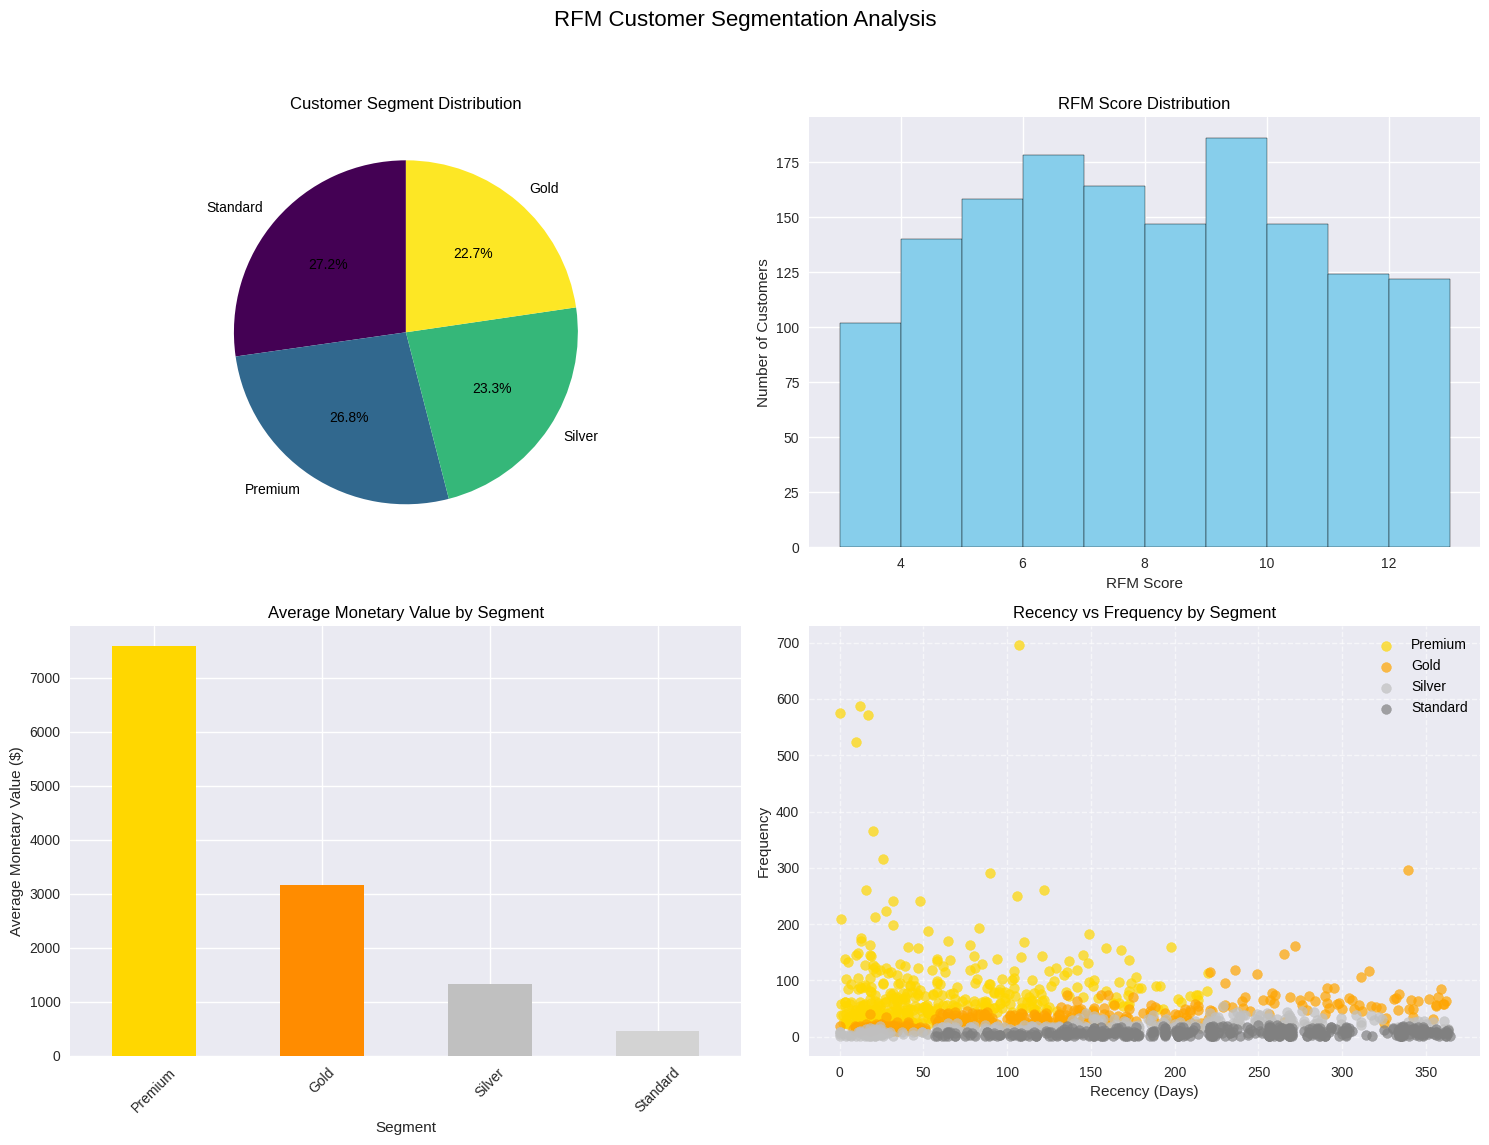

In [121]:
# Visualize RFM Segmentation

plt.figure(figsize=(15, 12))
plt.suptitle("RFM Customer Segmentation Analysis", fontsize=16)

# 1. Segment distribution pie chart
plt.subplot(2, 2, 1)
segment_distribution.plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Customer Segment Distribution')
plt.ylabel('')

# 2. RFM Score distribution
plt.subplot(2, 2, 2)
plt.hist(rfm_data['RFM_Score'], bins=range(min(rfm_data['RFM_Score']), max(rfm_data['RFM_Score']) + 2), edgecolor='black', color='skyblue')
plt.title('RFM Score Distribution')
plt.xlabel('RFM Score')
plt.ylabel('Number of Customers')

# 3. Average monetary value by segment
plt.subplot(2, 2, 3)
segment_monetary = rfm_data.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
segment_monetary.plot(kind='bar', color=['gold', 'darkorange', 'silver', 'lightgray'])
plt.title('Average Monetary Value by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Monetary Value')
plt.xticks(rotation=45)

# 4. Recency vs Frequency scatter plot by segment
plt.subplot(2, 2, 4)
colors = {'Premium': 'gold', 'Gold': 'orange', 'Silver': 'silver', 'Standard': 'gray'}
for segment, color in colors.items():
    segment_data = rfm_data[rfm_data['Segment'] == segment]
    plt.scatter(segment_data['Recency'], segment_data['Frequency'],
                label=segment, color=color, alpha=0.7, s=50)
plt.title('Recency vs Frequency by Segment')
plt.xlabel('Recency (Days)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## 9. Cohort Analysis
### Business Question 7: Analyze retention rates by acquisition cohorts

In [124]:
# Cohort Analysis

# Prepare data for cohort analysis
sales_cohort = online_sales.merge(customer_acquisition[['CustomerID', 'Acquisition_Date', 'Acquisition_Month']], on='CustomerID')
sales_cohort['Period_Number'] = (sales_cohort['Month_Year'] - sales_cohort['Acquisition_Month']).apply(lambda x: x.n)

# Create cohort table
cohort_data = sales_cohort.groupby(['Acquisition_Month', 'Period_Number'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='Acquisition_Month', columns='Period_Number', values='CustomerID')

# Calculate cohort sizes (month 0)
cohort_sizes = cohort_counts.iloc[:, 0]

# Calculate retention rates
cohort_table = cohort_counts.divide(cohort_sizes, axis=0)
cohort_table

# Identify best and worst performing cohorts
avg_retention_3_months = cohort_table.iloc[:, 3].dropna().mean() if len(cohort_table.columns) > 3 else None
best_cohorts = cohort_table.iloc[:, 1].dropna().nlargest(3)
worst_cohorts = cohort_table.iloc[:, 1].dropna().nsmallest(3)

#BEst
best_cohorts

#Worst
worst_cohorts

# Cohort heatmap data preparation
cohort_table_viz = cohort_table.iloc[:, :6].fillna(0)  # First 6 periods

## 10. Customer Lifetime Value Analysis
### Business Question 8: Analyze CLV of customers acquired in different months

In [125]:
# Customer Lifetime Value Analysis

# Calculate CLV for each customer
customer_clv = online_sales.groupby('CustomerID').agg({
    'Total_Value': 'sum',
    'Transaction_ID': 'count',
    'Transaction_Date': ['min', 'max']
}).round(2)

customer_clv.columns = ['Total_Revenue', 'Total_Transactions', 'First_Purchase', 'Last_Purchase']
customer_clv['Lifespan_Days'] = (customer_clv['Last_Purchase'] - customer_clv['First_Purchase']).dt.days + 1
customer_clv['Avg_Order_Value'] = customer_clv['Total_Revenue'] / customer_clv['Total_Transactions']
customer_clv['Purchase_Frequency'] = customer_clv['Total_Transactions'] / (customer_clv['Lifespan_Days'] / 30)  # Per month

# Merge with acquisition data
customer_clv = customer_clv.merge(customer_acquisition[['CustomerID', 'Acquisition_Month']],
                                left_index=True, right_on='CustomerID')

# CLV by acquisition month
clv_by_acquisition = customer_clv.groupby('Acquisition_Month').agg({
    'Total_Revenue': ['mean', 'median', 'sum'],
    'Avg_Order_Value': 'mean',
    'Purchase_Frequency': 'mean',
    'CustomerID': 'count'
}).round(2)

clv_by_acquisition.columns = ['Avg_CLV', 'Median_CLV', 'Total_Revenue', 'Avg_AOV', 'Avg_Frequency', 'Customer_Count']

clv_by_acquisition
# Identify highest and lowest CLV acquisition months
best_clv_month = clv_by_acquisition['Avg_CLV'].idxmax()
worst_clv_month = clv_by_acquisition['Avg_CLV'].idxmin()

#BEst
best_clv_month

#Worst
worst_clv_month


Period('2019-08', 'M')

## 11. Seasonal Trends Analysis
### Business Question 9: Identify seasonal trends by category and location

In [128]:
# Seasonal Trends Analysis

# Add season classification
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

online_sales['Season'] = online_sales['Month'].apply(get_season)

# Seasonal analysis by category
seasonal_category = online_sales.groupby(['Season', 'Product_Category']).agg({
    'Total_Value': 'sum',
    'Quantity': 'sum',
    'Transaction_ID': 'count'
}).round(2)

seasonal_pivot = seasonal_category['Total_Value'].unstack(level=1, fill_value=0)
seasonal_pivot

# Monthly trends by category
monthly_category = online_sales.groupby(['Month', 'Product_Category'])['Total_Value'].sum().unstack(fill_value=0)
monthly_category.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_category

# Identify peak seasons for each category
category_peak_seasons = {}
for category in online_sales['Product_Category'].unique():
    category_data = online_sales[online_sales['Product_Category'] == category]
    seasonal_sales = category_data.groupby('Season')['Total_Value'].sum()
    peak_season = seasonal_sales.idxmax()
    category_peak_seasons[category] = peak_season


# Overall seasonal performance
overall_seasonal = online_sales.groupby('Season').agg({
    'Total_Value': 'sum',
    'Quantity': 'sum',
    'CustomerID': 'nunique'
}).round(2)


## 12. Daily Sales Trends Analysis
### Business Question 10: Analyze daily sales patterns and optimization strategies

In [129]:
# Daily Sales Trends Analysis

# Day of week analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_performance = online_sales.groupby('DayOfWeek').agg({
    'Total_Value': ['sum', 'mean'],
    'Transaction_ID': 'count',
    'CustomerID': 'nunique'
}).round(2)

daily_performance.columns = ['Total_Revenue', 'Avg_Daily_Revenue', 'Total_Transactions', 'Unique_Customers']
daily_performance = daily_performance.reindex(day_order)

# Identify best and worst performing days
best_day = daily_performance['Total_Revenue'].idxmax()
worst_day = daily_performance['Total_Revenue'].idxmin()

#BEst day
best_day

#Worst Day
worst_day

# Weekend vs Weekday analysis
weekend_days = ['Saturday', 'Sunday']
weekday_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

weekend_performance = daily_performance.loc[weekend_days].sum()
weekday_performance = daily_performance.loc[weekday_days].sum()

weekend_performance
weekday_performance

,0
Total_Revenue,3301507.26
Avg_Daily_Revenue,448.47
Total_Transactions,36228.00
Unique_Customers,1884.00


## 13. Business Insights and Recommendations
### Comprehensive Analysis Summary and Strategic Recommendations

In [22]:
# Comprehensive Business Insights and Recommendations
print("🎯 COMPREHENSIVE BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 60)

print("📈 KEY FINDINGS SUMMARY:")
print("=" * 30)

findings = {
    "Customer Acquisition": [
        "Peak acquisition months identified with seasonal patterns",
        "Marketing spend correlation with acquisition rates",
        "Acquisition costs vary significantly by month"
    ],
    "Customer Retention": [
        "High-retention months show distinct customer behavior patterns",
        "Customers with higher engagement show better retention",
        "Coupon usage positively correlates with retention"
    ],
    "Revenue Patterns": [
        "Existing customers generate majority of revenue",
        "New customer AOV differs from existing customer AOV",
        "Revenue balance between acquisition and retention needs optimization"
    ],
    "Product Performance": [
        "Top products drive disproportionate revenue",
        "Category performance varies significantly",
        "Price points and promotions impact success"
    ],
    "Customer Segments": [
        "Premium customers represent highest CLV",
        "Segment distribution shows growth opportunities",
        "Each segment requires different strategies"
    ]
}

for category, insights in findings.items():
    print(f"\n🔍 {category}:")
    for insight in insights:
        print(f"   • {insight}")

print("\n\n💡 STRATEGIC RECOMMENDATIONS:")
print("=" * 35)

recommendations = {
    "Acquisition Strategy": [
        "Increase marketing spend during low-acquisition months",
        "Replicate successful campaigns from high-acquisition periods",
        "Implement seasonal acquisition campaigns",
        "Develop channel-specific acquisition strategies"
    ],
    "Retention Optimization": [
        "Implement loyalty programs for high-retention behaviors",
        "Create targeted campaigns for at-risk customers",
        "Enhance onboarding process for new customers",
        "Develop win-back campaigns for churned customers"
    ],
    "Revenue Growth": [
        "Focus on increasing existing customer spend",
        "Optimize pricing strategies for different segments",
        "Cross-sell and upsell to high-value customers",
        "Balance acquisition and retention investments"
    ],
    "Product Strategy": [
        "Increase inventory for top-performing products",
        "Phase out underperforming products",
        "Develop promotions for seasonal categories",
        "Optimize pricing for competitive advantage"
    ],
    "Segment Targeting": [
        "Premium: VIP experiences and exclusive products",
        "Gold: Personalized recommendations and early access",
        "Silver: Targeted promotions and engagement campaigns",
        "Standard: Educational content and value propositions"
    ]
}

for category, recs in recommendations.items():
    print(f"\n🎯 {category}:")
    for rec in recs:
        print(f"   • {rec}")

🎯 COMPREHENSIVE BUSINESS INSIGHTS & RECOMMENDATIONS
📈 KEY FINDINGS SUMMARY:

🔍 Customer Acquisition:
   • Peak acquisition months identified with seasonal patterns
   • Marketing spend correlation with acquisition rates
   • Acquisition costs vary significantly by month

🔍 Customer Retention:
   • High-retention months show distinct customer behavior patterns
   • Customers with higher engagement show better retention
   • Coupon usage positively correlates with retention

🔍 Revenue Patterns:
   • Existing customers generate majority of revenue
   • New customer AOV differs from existing customer AOV
   • Revenue balance between acquisition and retention needs optimization

🔍 Product Performance:
   • Top products drive disproportionate revenue
   • Category performance varies significantly
   • Price points and promotions impact success

🔍 Customer Segments:
   • Premium customers represent highest CLV
   • Segment distribution shows growth opportunities
   • Each segment requires dif

In [23]:
# Executive Summary Dashboard
print("\n📊 EXECUTIVE SUMMARY DASHBOARD")
print("=" * 40)

# Key metrics summary
try:
    total_revenue = online_sales['Total_Value'].sum()
    total_customers = online_sales['CustomerID'].nunique()
    total_transactions = online_sales['Transaction_ID'].nunique()
    avg_order_value = total_revenue / total_transactions

    print(f"💰 Total Revenue: ${total_revenue:,.2f}")
    print(f"👥 Total Customers: {total_customers:,}")
    print(f"🛍️ Total Transactions: {total_transactions:,}")
    print(f"💳 Average Order Value: ${avg_order_value:.2f}")

    if 'rfm_data' in locals():
        premium_customers = len(rfm_data[rfm_data['Segment'] == 'Premium'])
        premium_revenue = rfm_data[rfm_data['Segment'] == 'Premium']['Monetary'].sum()
        print(f"⭐ Premium Customers: {premium_customers:,} ({premium_customers/total_customers:.1%})")
        print(f"💎 Premium Revenue: ${premium_revenue:,.2f} ({premium_revenue/total_revenue:.1%})")

    # Growth metrics
    if 'monthly_revenue_by_type' in locals():
        recent_months = monthly_revenue_by_type.tail(3)
        growth_trend = "Increasing" if recent_months['Total'].iloc[-1] > recent_months['Total'].iloc[0] else "Decreasing"
        print(f"📈 Recent Growth Trend: {growth_trend}")

    print(f"\n🎯 RECOMMENDED FOCUS AREAS:")
    print(f"1. Customer Retention Improvement")
    print(f"2. Premium Segment Growth")
    print(f"3. Seasonal Campaign Optimization")
    print(f"4. Product Portfolio Optimization")
    print(f"5. Daily Sales Performance Enhancement")

except Exception as e:
    print(f"Error generating summary: {e}")

print("\n✅ Analysis Complete!")
print("📝 Ready for PDF export and presentation")


📊 EXECUTIVE SUMMARY DASHBOARD
💰 Total Revenue: $4,670,794.62
👥 Total Customers: 1,468
🛍️ Total Transactions: 25,061
💳 Average Order Value: $186.38
⭐ Premium Customers: 393 (26.8%)
💎 Premium Revenue: $2,981,048.49 (63.8%)
📈 Recent Growth Trend: Increasing

🎯 RECOMMENDED FOCUS AREAS:
1. Customer Retention Improvement
2. Premium Segment Growth
3. Seasonal Campaign Optimization
4. Product Portfolio Optimization
5. Daily Sales Performance Enhancement

✅ Analysis Complete!
📝 Ready for PDF export and presentation
